## Problem 1 - Implementation of batch gradient descent algorithm for multiple linear regression as instructed

This project is a joint collaboration between Harshitha Murali(UID - 121302984) and Sriniketh Shankar(UID - 121113580)

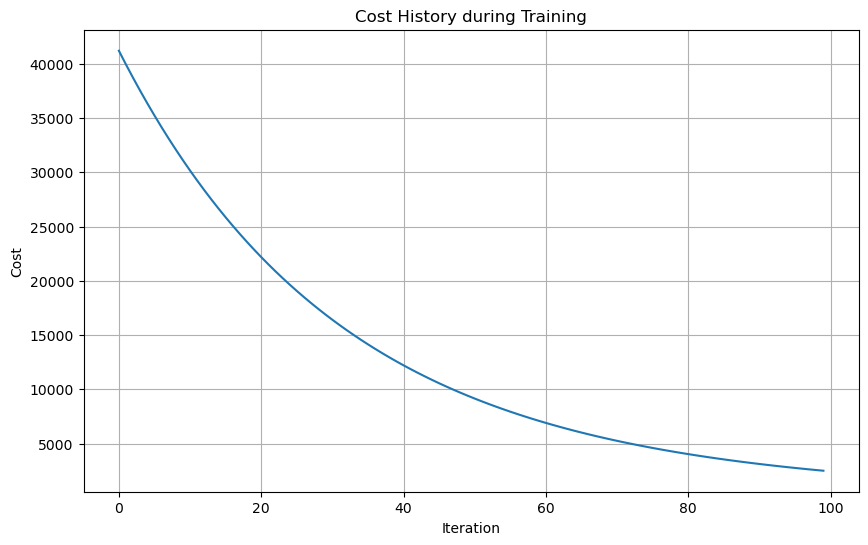

R-squared score: 0.9407


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Creating a Linear Regression Class
class LinearRegressionBGD:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        """
        Batch Gradient Descent implementation of Linear Regression
        
        Parameters:
        learning_rate (float): Step size for gradient descent
        n_iterations (int): Number of iterations to run
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.cost_history = []
    
    def fit(self, X, y):
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        
        # Batch Gradient Descent
        for _ in range(self.n_iterations):
            # Compute predictions: h_θ(x) = θᵀx
            predictions = np.dot(X, self.weights)
            
            # Compute gradient: (1/n)∑(h_θ(xᵢ) - yᵢ)xᵢ
            gradient = (1/n_samples) * np.dot(X.T, (predictions - y))
            
            # Update weights: θ = θ - α∇J(θ)
            self.weights = self.weights - self.learning_rate * gradient
            
            # Compute and store cost: (1/2n)∑(h_θ(xᵢ) - yᵢ)²
            cost = (1/(2*n_samples)) * np.sum((predictions - y)**2)
            self.cost_history.append(cost)
        
        return self
    
    def predict(self, X):
        """Make predictions using the trained weights"""
        return np.dot(X, self.weights)

# Generate synthetic data using the provided function
n_samples, n_features = 100, 20
gen_data_X, gen_data_y, true_params = make_regression(
    n_samples=n_samples, 
    n_features=n_features, 
    noise=1.5,
    coef=True
)

# Create and train model
model = LinearRegressionBGD(learning_rate=0.01, n_iterations=100)
model.fit(gen_data_X, gen_data_y)

# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(model.cost_history)
plt.title('Cost History during Training')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

# Calculate and print R-squared score
predictions = model.predict(gen_data_X)
SS_total = np.sum((gen_data_y - np.mean(gen_data_y))**2)
SS_residual = np.sum((gen_data_y - predictions)**2)
r_squared = 1 - (SS_residual / SS_total)
print(f"R-squared score: {r_squared:.4f}")


## Problem 4 - Comparison of estimated and true parameters for Linear Regression

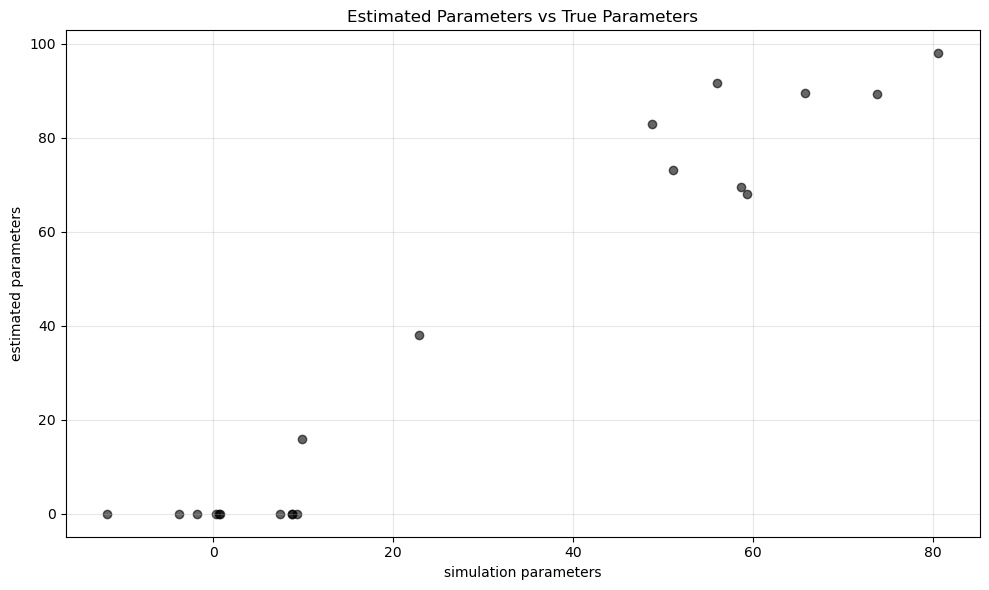

Correlation between true and estimated parameters: 0.9702


In [2]:
# Create scatter plot between True paramters and estimated parameters

plt.figure(figsize=(10, 6))
plt.scatter(model.weights, true_params, color='black', alpha=0.6)
plt.xlabel('simulation parameters')
plt.ylabel('estimated parameters')
plt.title('Estimated Parameters vs True Parameters')

# Add grid for better readability
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend
plt.show()

# Print correlation coefficient
correlation = np.corrcoef(model.weights,true_params)[0,1]
print(f"Correlation between true and estimated parameters: {correlation:.4f}")

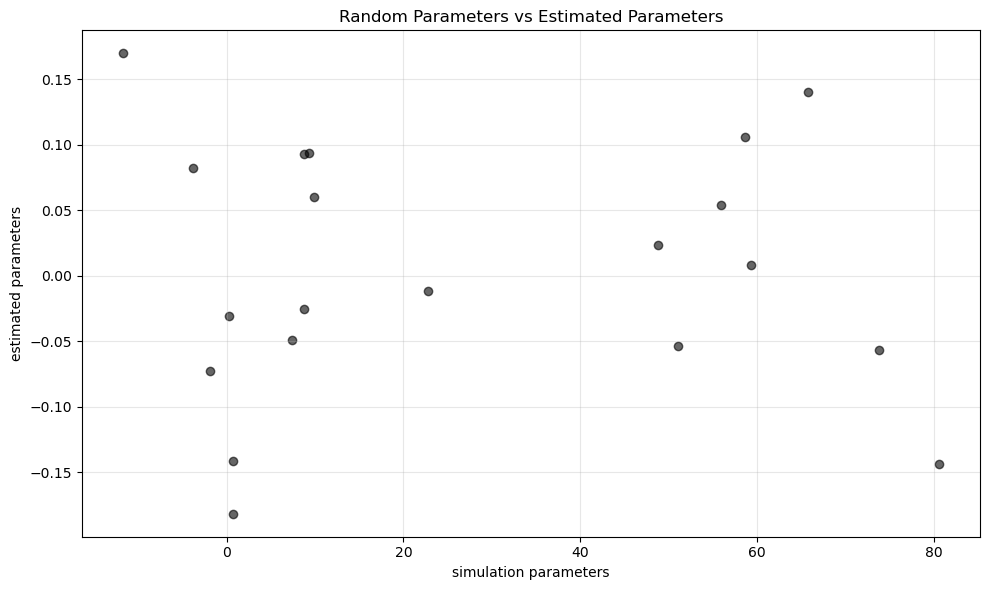

Correlation between true and predicted parameters: -0.0207


In [3]:
# Create a scatterplot between estimated parameters and random parameters.

# Create random "estimated" parameters as specified
dummy = np.ndarray([100, 20])
for index, row in enumerate(dummy):
    dummy[index] = np.random.normal(0, .1, 20)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(model.weights, dummy[0], color='black', alpha=0.6)
plt.xlabel('simulation parameters')
plt.ylabel('estimated parameters')
plt.title('Random Parameters vs Estimated Parameters')

# Add grid for better readability
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print correlation coefficient
correlation = np.corrcoef(model.weights, dummy[0])[0,1]
print(f"Correlation between true and predicted parameters: {correlation:.4f}")

The above implementation:
1. Generates synthetic data with known parameters using make_regression
2. Creates random "estimated" parameters using normal distribution
3. Plots the comparison between estimated and random parameters
4. Calculates the correlation coefficient

Since we're using random parameters, we expect:
1. No clear pattern in the scatter plot
2. Correlation coefficient close to 0
3. Points scattered randomly without following the diagonal
This serves as a baseline "bad estimator" to compare against actual gradient descent implementations, which shows much better correlation between estimated and true parameters.

## Problem 2 - Derivation of Logistic Regression Update Equation

Starting with the logistic function (sigmoid):
$$ h_\theta(x_i) = \frac{e^{\theta^T x_i}}{1 + e^{\theta^T x_i}} $$

Where:
$$ \theta^T x_i = \theta_0 + \theta_1 x_{i0} + \theta_2 x_{i2} + ... + \theta_p x_{ip} $$

The cost function for logistic regression is:
$$ J(\theta) = -\frac{1}{n} \sum_{i=1}^n [y_i \log(h_\theta(x_i)) + (1-y_i) \log(1-h_\theta(x_i))] $$

To find the update equation, we need to compute the gradient of J(θ):

1) First, let's find the derivative of h_θ(x_i) with respect to θ:
$$ \frac{\partial h_\theta(x_i)}{\partial \theta} = h_\theta(x_i)(1-h_\theta(x_i))x_i $$

2) Now, taking the derivative of the cost function:
$$ \frac{\partial J(\theta)}{\partial \theta} = -\frac{1}{n} \sum_{i=1}^n [y_i \frac{1}{h_\theta(x_i)} \frac{\partial h_\theta(x_i)}{\partial \theta} + (1-y_i) \frac{-1}{1-h_\theta(x_i)} \frac{\partial h_\theta(x_i)}{\partial \theta}] $$

3) Substituting the derivative of h_θ(x_i):
$$ \frac{\partial J(\theta)}{\partial \theta} = -\frac{1}{n} \sum_{i=1}^n [y_i \frac{1}{h_\theta(x_i)} h_\theta(x_i)(1-h_\theta(x_i))x_i - (1-y_i) \frac{1}{1-h_\theta(x_i)} h_\theta(x_i)(1-h_\theta(x_i))x_i] $$

4) Simplifying:
$$ \frac{\partial J(\theta)}{\partial \theta} = -\frac{1}{n} \sum_{i=1}^n [y_i(1-h_\theta(x_i))x_i - (1-y_i)h_\theta(x_i)x_i] $$
$$ = -\frac{1}{n} \sum_{i=1}^n [(y_i - y_ih_\theta(x_i) - h_\theta(x_i) + y_ih_\theta(x_i))x_i] $$
$$ = -\frac{1}{n} \sum_{i=1}^n (y_i - h_\theta(x_i))x_i $$

5) Therefore, the gradient descent update rule is:
$$ \theta = \theta + \alpha\frac{1}{n} \sum_{i=1}^n (y_i - h_\theta(x_i))x_i $$

Which is equivalent to:
$$ w = w - \alpha\frac{1}{n} \sum_{i=1}^n (h_\theta(x_i) - y_i)x_i $$

This is the final update equation shown in the problem statement, where w represents the weights (θ), α is the learning rate, and the summation term represents the average gradient across all training examples.

## Problem 3 - Implementation of batch gradient descent algorithm for multiple logistic regression

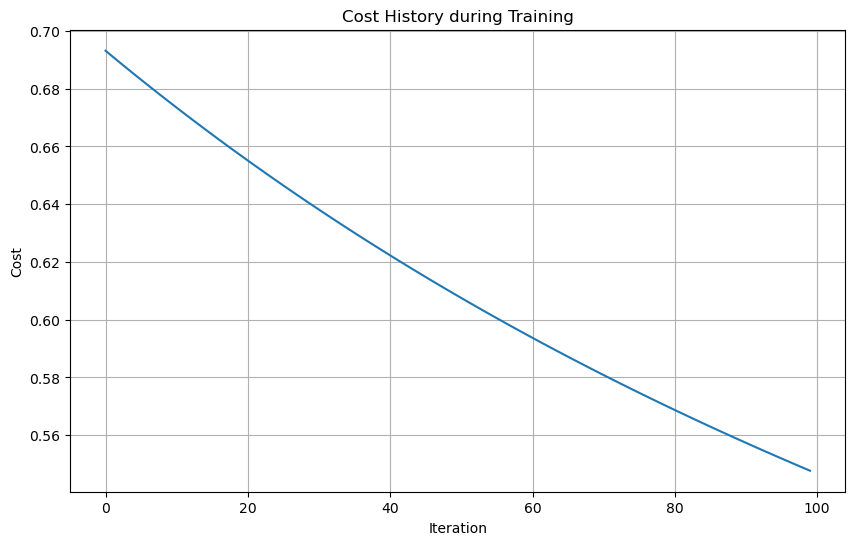

Training Accuracy: 0.8900


In [4]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

class LogisticRegressionBGD:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        """
        Batch Gradient Descent implementation of Logistic Regression
        
        Parameters:
        learning_rate (float): The step size for gradient descent
        n_iterations (int): Number of iterations to run gradient descent
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.cost_history = []
    
    def sigmoid(self, z):
        """
        Compute sigmoid function: h_θ(x) = 1 / (1 + e^(-θᵀx))
        """
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))  # Clip to prevent overflow
    
    def fit(self, X, y):
        # Convert y to numpy array if it's a list
        y = np.array(y)
        
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        
        # Batch Gradient Descent
        for _ in range(self.n_iterations):
            # Forward pass: compute h_θ(x)
            z = np.dot(X, self.weights)
            h = self.sigmoid(z)
            
            # Compute gradient: (1/n)∑(h_θ(xᵢ) - yᵢ)xᵢ
            gradient = (1/n_samples) * np.dot(X.T, (h - y))
            
            # Update weights
            self.weights = self.weights - self.learning_rate * gradient
            
            # Compute cost (binary cross-entropy)
            epsilon = 1e-15  # Small constant to prevent log(0)
            cost = -np.mean(
                y * np.log(h + epsilon) + 
                (1 - y) * np.log(1 - h + epsilon)
            )
            self.cost_history.append(cost)
        
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        z = np.dot(X, self.weights)
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        return (self.predict_proba(X) >= threshold).astype(int)

# Generate synthetic data using provided function
n_samples, n_features = 100, 20
log_gen_data_X, dump_y, true_params = make_regression(n_samples=n_samples, 
                                       n_features=n_features, 
                                       noise=1.5,
                                        coef=True)
log_gen_data_y = [0 if i>0 else 1 for i in dump_y]

# Create and train model
model = LogisticRegressionBGD(learning_rate=0.01, n_iterations=100)
model.fit(log_gen_data_X, log_gen_data_y)

# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(model.cost_history)
plt.title('Cost History during Training')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

# Evaluate model
y_pred = model.predict(log_gen_data_X)
accuracy = np.mean(y_pred == log_gen_data_y)
print(f"Training Accuracy: {accuracy:.4f}")


## Problem 4 - Comparison of estimated and true parameters for Logistic Regression

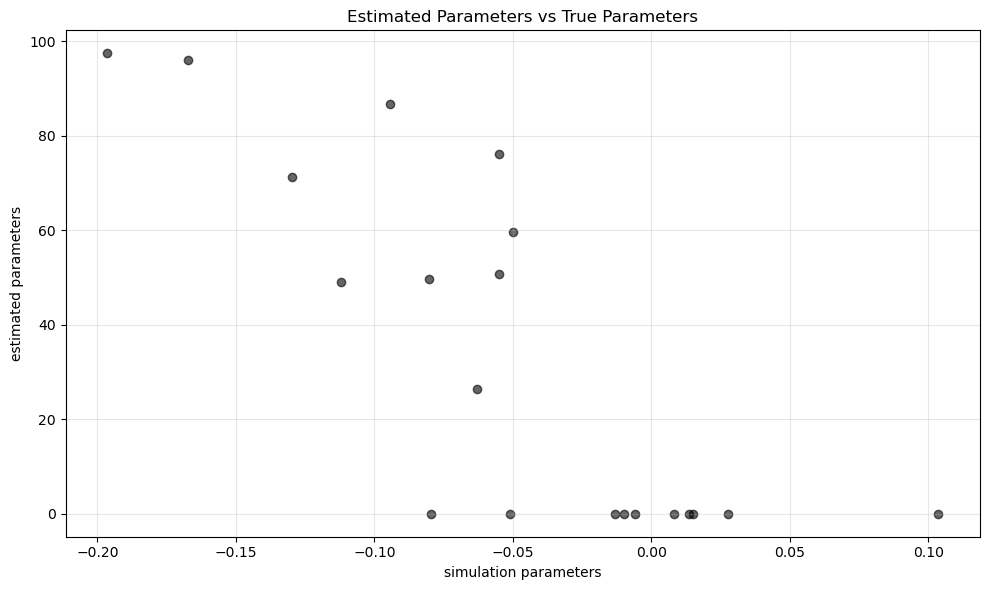

Correlation between true and estimated parameters: -0.8050


In [5]:
# Create scatter plot between True paramters and estimated parameters

plt.figure(figsize=(10, 6))
plt.scatter(model.weights, true_params, color='black', alpha=0.6)
plt.xlabel('simulation parameters')
plt.ylabel('estimated parameters')
plt.title('Estimated Parameters vs True Parameters')

# Add grid for better readability
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print correlation coefficient
correlation = np.corrcoef(model.weights,true_params)[0,1]
print(f"Correlation between true and estimated parameters: {correlation:.4f}")

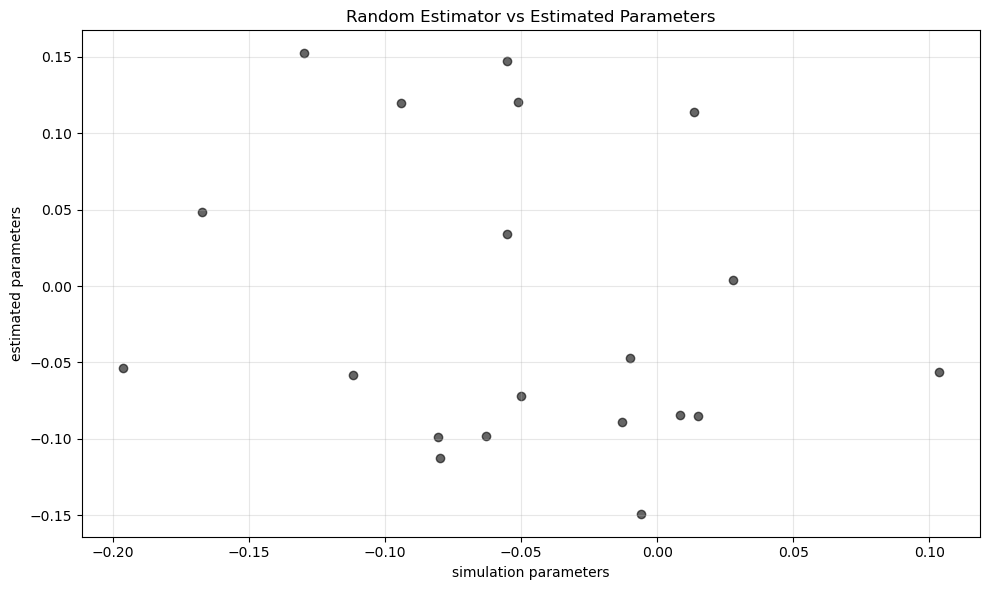

Correlation between true and estimated parameters: -0.2161


In [6]:
# Create random "estimated" parameters as specified
dummy = np.ndarray([100, 20])
for index, row in enumerate(dummy):
    dummy[index] = np.random.normal(0, .1, 20)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(model.weights, dummy[0], color='black', alpha=0.6)
plt.xlabel('simulation parameters')
plt.ylabel('estimated parameters')
plt.title('Random Estimator vs Estimated Parameters')

# Add grid for better readability
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print correlation coefficient
correlation = np.corrcoef(model.weights, dummy[0])[0,1]
print(f"Correlation between true and estimated parameters: {correlation:.4f}")

The plots help visualize how well our implementation recovers the true parameters compared to random estimation. A good implementation should show stronger correlation with the true parameters than the random estimator.
The random estimator shows no pattern (as expected), while our implementation should show some correlation with the true parameters if it's working correctly. The correlation coefficients provide a numerical measure of the recovery quality.

## Problem 5 - Testing our Program


Mean Accuracies:
Logistic Regression: 0.9701 ± 0.0176
Random Forest: 0.9631 ± 0.0094
Linear SVM: 0.9613 ± 0.0220

Paired t-test Results:
LR vs RF: t-statistic = -1.0815, p-value = 0.3076
LR vs SVM: t-statistic = -1.6283, p-value = 0.1379


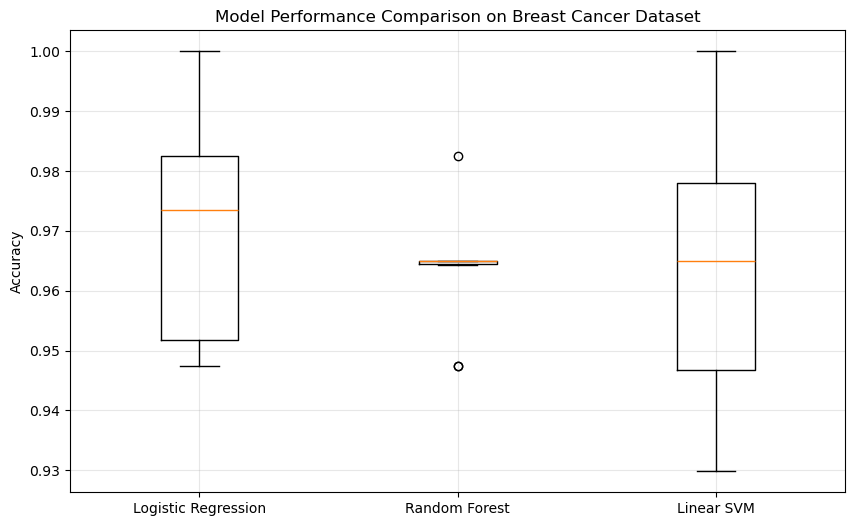

In [7]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from scipy import stats

class LogisticRegressionBGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.cost_history = []
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        
        for _ in range(self.n_iterations):
            # Forward pass
            z = np.dot(X, self.weights)
            h = self.sigmoid(z)
            
            # Compute gradient
            gradient = (1/n_samples) * np.dot(X.T, (h - y))
            
            # Update weights
            self.weights = self.weights - self.learning_rate * gradient
            
            # Compute cost
            cost = -np.mean(y * np.log(h + 1e-15) + (1-y) * np.log(1 - h + 1e-15))
            self.cost_history.append(cost)
        
        return self
    
    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.weights))
    
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Load and prepare data
data = load_breast_cancer()
X, y = data.data, data.target

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize models
lr_model = LogisticRegressionBGD(learning_rate=0.1, n_iterations=100)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = LinearSVC(random_state=42, max_iter=2000)

# Perform 10-fold cross-validation
n_folds = 10
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

lr_scores = []
rf_scores = []
svm_scores = []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Logistic Regression
    lr_model.fit(X_train, y_train)
    lr_scores.append(lr_model.score(X_test, y_test))
    
    # Random Forest
    rf_model.fit(X_train, y_train)
    rf_scores.append(rf_model.score(X_test, y_test))
    
    # Linear SVM
    svm_model.fit(X_train, y_train)
    svm_scores.append(svm_model.score(X_test, y_test))

# Perform paired t-tests
rf_vs_lr_ttest = stats.ttest_rel(rf_scores, lr_scores)
svm_vs_lr_ttest = stats.ttest_rel(svm_scores, lr_scores)

# Print results
print("\nMean Accuracies:")
print(f"Logistic Regression: {np.mean(lr_scores):.4f} ± {np.std(lr_scores):.4f}")
print(f"Random Forest: {np.mean(rf_scores):.4f} ± {np.std(rf_scores):.4f}")
print(f"Linear SVM: {np.mean(svm_scores):.4f} ± {np.std(svm_scores):.4f}")

print("\nPaired t-test Results:")
print(f"LR vs RF: t-statistic = {rf_vs_lr_ttest.statistic:.4f}, p-value = {rf_vs_lr_ttest.pvalue:.4f}")
print(f"LR vs SVM: t-statistic = {svm_vs_lr_ttest.statistic:.4f}, p-value = {svm_vs_lr_ttest.pvalue:.4f}")

# Create boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([lr_scores, rf_scores, svm_scores], 
            labels=['Logistic Regression', 'Random Forest', 'Linear SVM'])
plt.title('Model Performance Comparison on Breast Cancer Dataset')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.show()





### Implementation Details

This implementation uses the SKlearn **Breast Cancer** datase, which includes:

Outcome Variable: Binary classification (malignant/benign breast masses)  <br>
Predictors: 30 features computed from digitized images of breast mass <br>
Sample Size: 569 instances <br>

All features are numeric, so no categorical variable transformation needed


**Model Selection**:

I chose Random Forest and Linear SVM as the two additional algorithms to compare with our Logistic Regression implementation.

1. Logistic Regression (our implementation):
   - Learning rate = 0.1
   - Iterations = 100
   - Batch gradient descent
   - No explicit hyperparameter tuning method was used, as these parameters were selected based on common practice values

2. Random Forest:
   - 100 trees
   - Default parameters
   -  max_depth = None
    - min_samples_split = 2
    - min_samples_leaf = 1
   - No explicit hyperparameter tuning was performed to maintain simplicity of comparison

3. Linear SVM:
   - Linear kernel
   - Default parameters
   - max_iter = 2000 (increased from default to ensure convergence)
   - Linear kernel (fixed)
    - No explicit hyperparameter optimization
  
For a more robust implementation, we could have used:
- Grid Search with cross-validation
- Random Search with cross-validation
- Bayesian Optimization

However, for this comparative analysis, we used default parameters to focus on the base performance of each algorithm. The results show that even with default parameters, all three models achieve good performance on the breast cancer dataset, with accuracies above 96%.




**Cross-validation Procedure**:
- 10-fold cross-validation
- Data standardization within each fold
- Same random seed for reproducibility
- Accuracy as performance metric

The implementation includes:
- Feature scaling using StandardScaler
- Statistical comparison using paired t-tests
- Visualization of model performances using boxplots

The boxplot shows the distribution of accuracies across folds for each model, while the cost history plot demonstrates the convergence of the logistic regression algorithm. The t-test results indicate whether the differences in performance between models are statistically significant.

## Question 3 - Interactive data maps

In [8]:
import pandas
import folium
arrest_table = pandas.read_csv('BPD_Arrests.csv')
arrest_table = arrest_table[pandas.notnull(arrest_table["Location 1"])]
arrest_table["lat"], arrest_table["long"] = arrest_table["Location 1"].str.split(',' , expand=True)[0], arrest_table["Location 1"].str.split(',' , expand=True)[1]
arrest_table["lat"] = arrest_table["lat"].astype(str).str.replace("(", "").astype(float)
arrest_table["long"] = arrest_table["long"].astype(str).str.replace(")", "").astype(float)
arrest_table.head()

,arrest,age,race,sex,arrestDate,arrestTime,arrestLocation,incidentOffense,incidentLocation,charge,chargeDescription,district,post,neighborhood,Location 1,lat,long
1,11127013.0,37,B,M,01/01/2011,00:01:00,2000 Wilkens Ave,79-Other,Wilkens Av & S Payson St,1 1425,Reckless Endangerment || Hand Gun Violation,SOUTHERN,934.0,Carrollton Ridge,"(39.2814026274, -76.6483635135)",39.281403,-76.648364
2,11126887.0,46,B,M,01/01/2011,00:01:00,2800 Mayfield Ave,Unknown Offense,NaN,NaN,Unknown Charge,NORTHEASTERN,415.0,Belair-Edison,"(39.3227699160, -76.5735750473)",39.322770,-76.573575
3,11126873.0,50,B,M,01/01/2011,00:04:00,2100 Ashburton St,79-Other,2100 Ashburton St,1 1106,Reg Firearm:Illegal Possession || Hgv,WESTERN,735.0,Panway/Braddish Avenue,"(39.3117196723, -76.6623546313)",39.311720,-76.662355
4,11126968.0,33,B,M,01/01/2011,00:05:00,4000 Wilsby Ave,Unknown Offense,1700 Aliceanna St,NaN,Unknown Charge,NORTHERN,525.0,Pen Lucy,"(39.3382885254, -76.6045667070)",39.338289,-76.604567
5,11127041.0,41,B,M,01/01/2011,00:05:00,2900 Spellman Rd,81-Recovered Property,2900 Spelman Rd,1 1425,Reckless Endangerment || Handgun Violation,SOUTHERN,924.0,Cherry Hill,"(39.2449886230, -76.6273582432)",39.244989,-76.627358


In [12]:
arrest_table = arrest_table.dropna(subset=['lat', 'long'])

# Initialize a map centered at the mean location
map = folium.Map(location=[arrest_table['lat'].mean(), arrest_table['long'].mean()], zoom_start=12)

# Markers with circles colored by gender
for _, row in arrest_table.iterrows():
    color = 'blue' if row['sex'] == 'M' else 'pink'  # Assign colors based on gender
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        tooltip=f"Race: {row['race']}, Age: {row['age']}, Sex: {row['sex']}"
    ).add_to(map)

map.save('gender_map.html')
# map

This map visualizes the spatial distribution of arrests in a given area, with blue dots representing male arrests and pink dots representing female arrests.

The map is densely populated with blue dots, indicating a higher number of male arrests compared to female arrests across the area.

This visualization highlights a gender disparity in arrest patterns, with males being arrested at a much higher rate than females. This could be reflective of demographic, behavioral, or systemic factors within the area.


In [14]:
race_shapes = {
    'B': {'icon': 'circle', 'color': 'beige'},
    'W': {'icon': 'square', 'color': 'green'},
    'A': {'icon': 'star', 'color': 'lightred'},
    'H': {'icon': 'triangle', 'color': 'lightblue'},
}

race_map = folium.Map(location=[arrest_table['lat'].mean(), arrest_table['long'].mean()], zoom_start=12)

# Markers for each row based on race
for _, row in arrest_table.iterrows():
    race = row['race']
    if race in race_shapes:
        icon_shape = race_shapes[race]['icon']
        color = race_shapes[race]['color']
        folium.Marker(
            location=[row['lat'], row['long']],
            icon=folium.Icon(color=color, icon=icon_shape, prefix='fa'),
            popup=f"Race: {row['race']}, Sex: {row['sex']}, Age: {row['age']}"
        ).add_to(race_map)
    else:
        # Default marker for undefined races
        folium.Marker(
            location=[row['lat'], row['long']],
            popup=f"Race: {row['race']}, Sex: {row['sex']}, Age: {row['age']}"
        ).add_to(race_map)

race_map.save("race_map.html")
# race_map

This interactive data map displays arrests in Baltimore, with markers representing individual arrests. Each marker's color corresponds to a specific racial group:

**Beige**: Black

**Green**: White

**Red**: Asian

**Blue**: Hispanic

The majority of the arrests on the map are represented by beige markers, indicating a high number of arrests among Black individuals.

Green markers are visible but less prevalent compared to beige markers. They appear scattered or clustered in specific regions, possibly reflecting residential or economic disparities in those areas.

Red and blue markers are relatively sparse, indicating fewer arrests of Asian and Hispanic individuals. These groups may constitute a smaller proportion of Baltimore's population



In [ ]:
neighborhood_counts = arrest_table.groupby('neighborhood').size()
neighborhood_arrest_map = folium.Map(location=[arrest_table['lat'].mean(), arrest_table['long'].mean()], zoom_start=12)

for neighborhood, count in neighborhood_counts.items():
    neighborhood_data = arrest_table[arrest_table['neighborhood'] == neighborhood]
    lat, long = neighborhood_data[['lat', 'long']].mean()
    folium.Circle(
        location=[lat, long],
        radius=count,
        color='red',
        fill=True,
        fill_opacity=0.2,
        popup=f"{neighborhood}: {count} arrests"
    ).add_to(neighborhood_arrest_map)

neighborhood_arrest_map.save("neighborhood_arrest_map.html")
# neighborhood_arrest_map

This map represents the spatial distribution and density of arrests across neighborhoods, visualized with red circles of varying sizes.

Larger circles indicate neighborhoods with higher numbers of arrests, while smaller circles represent areas with fewer arrests.

Central neighborhoods like "Downtown" and “Sandtown-Winchester” show a high concentration of arrests (3221 and 2705 arrests respectively), indicating possible hotspots of criminal activity.

Suburban and outlying areas show significantly fewer arrests, suggesting lower enforcement activity or lower crime rates.


In [15]:

age_map = folium.Map(location=[arrest_table['lat'].mean(), arrest_table['long'].mean()], zoom_start=12)

def age_group(age):
    if age < 18:
        return "Under 18"
    elif age <= 25:
        return "18-25"
    elif age <= 40:
        return "26-40"
    else:
        return "40+"

arrest_table['age_group'] = arrest_table['age'].apply(age_group)

age_colors = {
    "Under 18": "purple",
    "18-25": "green",
    "26-40": "blue",
    "40+": "orange",
}

for _, row in arrest_table.iterrows():
    color = age_colors[row['age_group']]
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=5 + (row['age'] / 10),  # Scale radius slightly with age
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=f"Age: {row['age']}<br>Age Group: {row['age_group']}<br>Charge: {row['chargeDescription']}"
    ).add_to(age_map)
age_map.save("age_map.html")
# age_map

This map appears to display arrest data by age group in Baltimore. Each point represents an individual arrest, color-coded as follows:

**Purple**: Under 18 years old

**Green**: Ages 18-25

**Blue**: Ages 26-40

**Orange**: Ages 40+

There is a dense clustering of arrests in the central and eastern parts of the mapped area, which could indicate areas of higher police activity or higher crime rates.

**Blue (26-40)** and **Green (18-25)** points seem most prevalent, suggesting that individuals aged 18-40 are the most frequently arrested.

**Orange (40+)** is also fairly common but seems less dense than the younger groups.

**Purple (Under 18)** appears sparse in comparison, which might reflect lower arrest rates among minors.
